In [40]:

import xarray as xr
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timedelta
import tempfile
import zipfile
import rioxarray
import regionmask
import os

# Configuration
BOUNDARY_PATH = Path("/data0/nksp2/skagit/skagit_2/skagit-met/data/GIS/SkagitBoundary.json")
DISCHARGE_PATH = Path("/data0/nksp2/skagit/skagit_2/skagit-met/experiments_2/data/usgs_12200500_discharge.rdb")

# Data paths
conus_data_path = Path("/data0/hernanqd/instance_2021_data/preparing_datasets/CONUS404/hourly_ar_non_ar_events")
ucla_data_path = Path("/data0/hernanqd/instance_2021_data/hourly_ar_non_ar_events")
ucla_coords_file = Path("/data0/hernanqd/instance_2021_data/preparing_datasets/UCLA/wrfinput_d02_coord.nc")
pnnl_grid_file = Path("/data0/skagit_met/data_transfer/data/PNNL/historical/SERDP6km.geo_em.d01.nc")

# PRISM data
VAULT_DIR = "/data0/skagit_met/data_transfer/data"
BASE_DIR = "/data0/hernanqd/plots_code/skagit_basin_de"
HUC8_GEO = Path(BASE_DIR) / "data/GIS/SkagitSubBasin_HUC8.geojson"
PRISM_ROOT = Path(VAULT_DIR) / "prism_new_hq"
SNOTEL_DATA_BASE = Path(BASE_DIR) / "data/hourly_snotel"

In [41]:
snotel_ds = xr.open_zarr(SNOTEL_DATA_BASE / "1990-11-21_1990-11-30_SNOTEL_hourly_data.zarr")
snotel_ds

<xarray.Dataset> Size: 2kB
Dimensions:                    (time: 35, site: 2)
Coordinates:
  * time                       (time) datetime64[ns] 280B 1990-11-21T08:00:00...
  * site                       (site) <U11 88B '711:WA:SNTL' '817:WA:SNTL'
    elevation_ft               (site) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
    lat                        (site) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
    lon                        (site) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
    site_name                  (site) object 16B dask.array<chunksize=(2,), meta=np.ndarray>
Data variables:
    ACCUMULATED PRECIPITATION  (time, site) float64 560B dask.array<chunksize=(35, 2), meta=np.ndarray>
    AIR TEMP                   (time, site) float64 560B dask.array<chunksize=(35, 2), meta=np.ndarray>
    SWE                        (time, site) float64 560B dask.array<chunksize=(35, 2), meta=np.ndarray>

In [42]:
# Subtract the first value from all values to reset to zero at storm start
storm_precip = snotel_ds['ACCUMULATED PRECIPITATION'] - snotel_ds['ACCUMULATED PRECIPITATION'].isel(time=0)

storm_precip

<xarray.DataArray 'ACCUMULATED PRECIPITATION' (time: 35, site: 2)> Size: 560B
dask.array<sub, shape=(35, 2), dtype=float64, chunksize=(35, 2), chunktype=numpy.ndarray>
Coordinates:
  * time          (time) datetime64[ns] 280B 1990-11-21T08:00:00 ... 1990-11-...
  * site          (site) <U11 88B '711:WA:SNTL' '817:WA:SNTL'
    elevation_ft  (site) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
    lat           (site) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
    lon           (site) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
    site_name     (site) object 16B dask.array<chunksize=(2,), meta=np.ndarray>

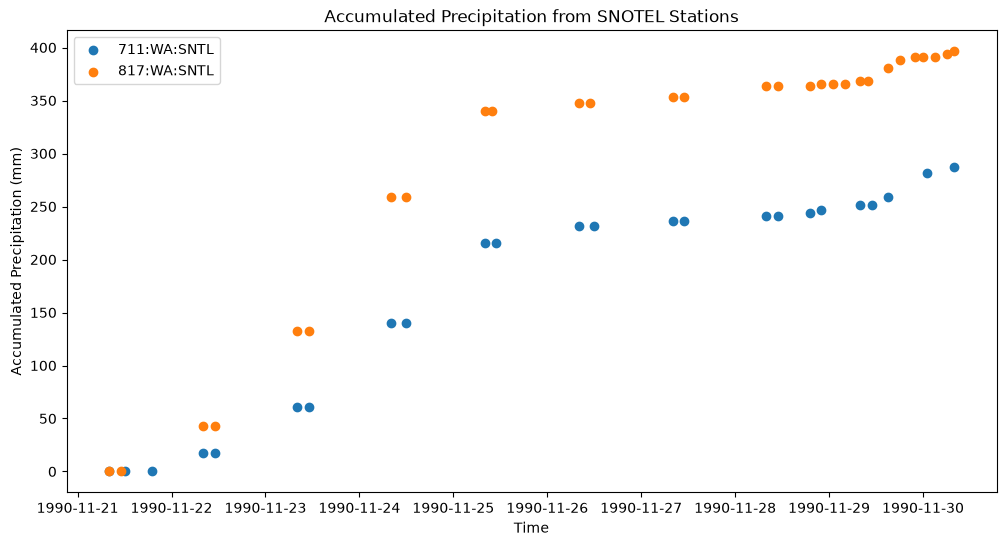

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

plt.scatter(storm_precip.time, storm_precip.sel(site='711:WA:SNTL').values * 25.4, label='711:WA:SNTL') 
plt.scatter(storm_precip.time, storm_precip.sel(site='817:WA:SNTL').values * 25.4, label='817:WA:SNTL') 

plt.title('Accumulated Precipitation from SNOTEL Stations')
plt.xlabel('Time')
plt.ylabel('Accumulated Precipitation (mm)')

plt.legend()

In [44]:
# Compute daily precipitation from accumulated values
daily_precip = (snotel_ds['ACCUMULATED PRECIPITATION']
                # .resample(time='1D')
                # .last()
                .diff(dim='time'))

daily_precip


<xarray.DataArray 'ACCUMULATED PRECIPITATION' (time: 34, site: 2)> Size: 544B
dask.array<sub, shape=(34, 2), dtype=float64, chunksize=(34, 2), chunktype=numpy.ndarray>
Coordinates:
  * time          (time) datetime64[ns] 272B 1990-11-21T11:00:00 ... 1990-11-...
  * site          (site) <U11 88B '711:WA:SNTL' '817:WA:SNTL'
    elevation_ft  (site) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
    lat           (site) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
    lon           (site) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
    site_name     (site) object 16B dask.array<chunksize=(2,), meta=np.ndarray>

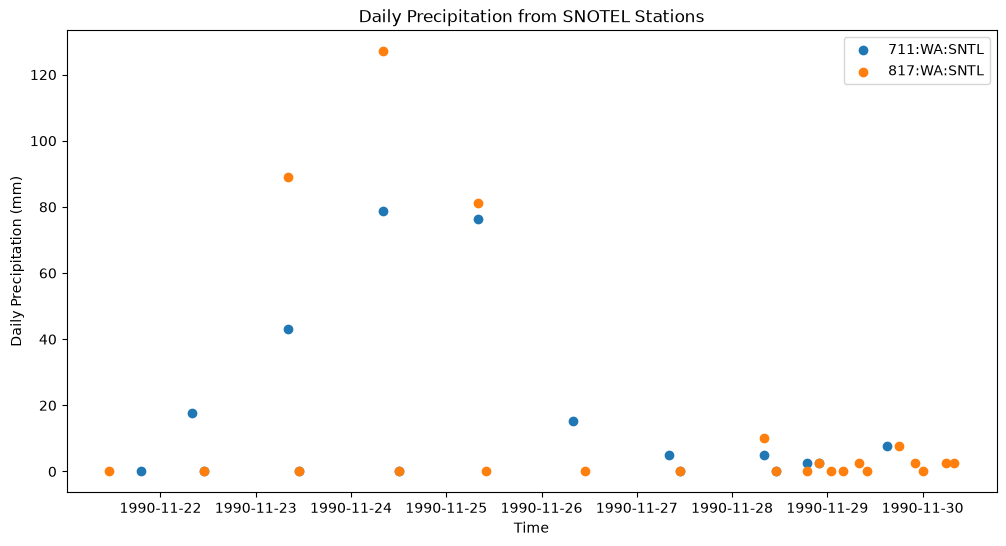

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

plt.scatter(daily_precip.time, daily_precip.sel(site='711:WA:SNTL').values * 25.4, label='711:WA:SNTL') 
plt.scatter(daily_precip.time, daily_precip.sel(site='817:WA:SNTL').values * 25.4, label='817:WA:SNTL') 

# mean = daily_precip.mean(dim='site')
# plt.scatter(daily_precip.time, mean.values, label='Mean')

plt.title('Daily Precipitation from SNOTEL Stations')
plt.xlabel('Time')
plt.ylabel('Daily Precipitation (mm)')

plt.legend()